In [3]:
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import optuna.visualization as vis
from datetime import datetime
from sklearn.model_selection import cross_val_score
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from utils.model_utils import open_best_model, get_best_model_name, save_optimized_model
from constants.separated import X_train,y_train
from constants.scaled import  X_train_scaled,y_train_scaled
from IPython.display import Audio, display
import winsound
import numpy as np

In [5]:
def notify_optimization_complete(duration_ms=1000*6):
    """Notifica que la optimización ha terminado usando diferentes métodos."""
    try:
        winsound.Beep(440, duration_ms)
    except:
        try:
            frequency = 440
            t = np.linspace(0, 1, 44100)
            tone = np.sin(2*np.pi*frequency*t)
            display(Audio(tone, rate=44100, autoplay=True))
        except:
            print("\n" + "="*50)
            print("🔔 ¡OPTIMIZACIÓN COMPLETADA! 🔔")
            print("="*50 + "\n")


In [6]:
def is_scaled_model(model_name: str) -> bool:
    """Determine if the model uses scaled data based on its name."""
    scaled_models = ['rf4', 'rf5', 'rf6', 'xgb2']
    return any(name in model_name for name in scaled_models)

In [7]:
def print_progress_callback(study, trial):
    """Callback para mostrar progreso detallado."""
    elapsed_time = datetime.now() - study.user_attrs["start_time"]
    completed_trials = len(study.get_trials(states=[optuna.trial.TrialState.COMPLETE]))
    
    if trial.number == 0:
        study.set_user_attr("first_value", trial.value)
        improvement = 0.0
    else:
        first_value = study.user_attrs.get("first_value", trial.value)
        improvement = ((trial.value - first_value) / abs(first_value) * 100)
    
    print(f"\nPrueba {trial.number}:")
    print(f"  Valor: {trial.value:.4f}")
    print(f"  Tiempo transcurrido: {elapsed_time}")
    print(f"  Pruebas completadas: {completed_trials}/{study.user_attrs['n_trials']}")
    print(f"  Mejor valor hasta ahora: {study.best_value:.4f}")
    if trial.number > 0:
        print(f"  Mejora sobre primera prueba: {improvement:.2f}%")

In [8]:
def objective_xgb(trial, X, y):
    """Función objetivo optimizada para XGBoost."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 5),
        'objective': 'binary:logistic',
        'random_state': 42
    }
    
    model = xgb.XGBClassifier(**params)
    scores = cross_val_score(model, X, y, cv=5, scoring='balanced_accuracy', n_jobs=-1)
    return scores.mean()

In [9]:
def objective_rf(trial, X, y):
    """Función objetivo optimizada para Random Forest."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample']),
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X, y, cv=5, scoring='balanced_accuracy', n_jobs=-1)
    return scores.mean()

Cargar el mejor modelo a optimizar

In [10]:
print("Loading best model...")
best_model = open_best_model()
print("Best model information:")
print(f"Model type: {type(best_model).__name__}")

Loading best model...
Best model information:
Model type: XGBClassifier


Determinamos el tipo de datos a utilizar

In [11]:
model_name = get_best_model_name()
print("model_name", model_name)
use_scaled_data = is_scaled_model(model_name)

if use_scaled_data:
    print("Using scaled data for optimization")
    X = X_train_scaled
    y = y_train_scaled.values.ravel()
else:
    print("Using original (unscaled) data for optimization")
    X = X_train
    y = y_train.values.ravel()

model_name xgb1
Using original (unscaled) data for optimization


Configuramos el estudio de optimizacion

In [12]:
sampler = TPESampler(
    n_startup_trials=5,
    multivariate=True,
    seed=42
)

pruner = MedianPruner(
    n_startup_trials=5,
    n_warmup_steps=5,
    interval_steps=1
)

study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    pruner=pruner
)

[I 2025-04-29 17:20:31,109] A new study created in memory with name: no-name-fdacbf9d-5be2-40e2-922b-3e1e4a76665d


Configuramos los parametros

In [13]:
n_trials = 2
timeout = 3600

Congfiguramos la hora de inicio de la optimizacion

In [14]:
study.set_user_attr("start_time", datetime.now())
study.set_user_attr("n_trials", n_trials)

Seleccionamos la funcion objetivo apopiada

In [15]:
if isinstance(best_model, xgb.XGBClassifier):
    objective = lambda trial: objective_xgb(trial, X, y)
    print("Optimizing XGBoost model")
else:
    objective = lambda trial: objective_rf(trial, X, y)
    print("Optimizing RandomForest model")

Optimizing XGBoost model


Ejecutamos el proceso de optimizacion

In [16]:
try:
    print("\nIniciando optimización...")
    print(f"Tiempo máximo: {timeout} segundos")
    print(f"Número máximo de pruebas: {n_trials}")
    
    study.optimize(
        objective,
        n_trials=n_trials,
        timeout=timeout,
        callbacks=[print_progress_callback],
        n_jobs=-1,
        gc_after_trial=True,
        show_progress_bar=True
    )
except KeyboardInterrupt:
    print("\nOptimización interrumpida por el usuario.")
finally:
    notify_optimization_complete()
    
    # Imprimir resultados finales
    print("\nResultados de la Optimización")
    print("=" * 50)
    print(f"Número de pruebas completadas: {len(study.trials)}")
    print(f"\nMejor prueba:")
    trial = study.best_trial
    print(f"  Valor: {trial.value:.4f}")
    print("\n  Parámetros:")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")
    
    start_time = study.user_attrs.get("start_time")
    if start_time is not None:
        total_time = datetime.now() - start_time
        print(f"\nTiempo total de optimización: {total_time}")
    
    if len(study.trials) > 1:
        first_value = study.user_attrs.get("first_value")
        if first_value is not None:
            total_improvement = ((study.best_value - first_value) / abs(first_value) * 100)
            print(f"Mejora total: {total_improvement:.2f}%")


Iniciando optimización...
Tiempo máximo: 3600 segundos
Número máximo de pruebas: 2


Best trial: 0. Best value: 0.533375:  50%|█████     | 1/2 [00:22<00:22, 22.80s/it, 22.80/3600 seconds]

[I 2025-04-29 17:20:53,818] Trial 0 finished with value: 0.5333748818839117 and parameters: {'n_estimators': 506, 'max_depth': 3, 'learning_rate': 0.0013093905319998321, 'min_child_weight': 4, 'gamma': 0.007130224869724489, 'subsample': 0.7525787653717348, 'colsample_bytree': 0.7964171233289259, 'reg_alpha': 0.0007729747573238817, 'reg_lambda': 2.7471097250482382e-08, 'scale_pos_weight': 2.813798638983997}. Best is trial 0 with value: 0.5333748818839117.

Prueba 0:
  Valor: 0.5334
  Tiempo transcurrido: 0:00:22.831743
  Pruebas completadas: 1/2
  Mejor valor hasta ahora: 0.5334


Best trial: 1. Best value: 0.902723: 100%|██████████| 2/2 [00:38<00:00, 19.07s/it, 38.14/3600 seconds]


[I 2025-04-29 17:21:09,203] Trial 1 finished with value: 0.902722536564934 and parameters: {'n_estimators': 826, 'max_depth': 3, 'learning_rate': 0.09984918067165698, 'min_child_weight': 4, 'gamma': 0.11966723736060576, 'subsample': 0.74688931326115, 'colsample_bytree': 0.8328733319853615, 'reg_alpha': 0.032666898678306876, 'reg_lambda': 2.9199019623187365e-05, 'scale_pos_weight': 1.7408561504100666}. Best is trial 1 with value: 0.902722536564934.

Prueba 1:
  Valor: 0.9027
  Tiempo transcurrido: 0:00:38.174626
  Pruebas completadas: 2/2
  Mejor valor hasta ahora: 0.9027
  Mejora sobre primera prueba: 69.25%

Resultados de la Optimización
Número de pruebas completadas: 2

Mejor prueba:
  Valor: 0.9027

  Parámetros:
    n_estimators: 826
    max_depth: 3
    learning_rate: 0.09984918067165698
    min_child_weight: 4
    gamma: 0.11966723736060576
    subsample: 0.74688931326115
    colsample_bytree: 0.8328733319853615
    reg_alpha: 0.032666898678306876
    reg_lambda: 2.91990196231873

Creación y guardado del modelo final

In [17]:
if isinstance(best_model, xgb.XGBClassifier):
    optimized_model = xgb.XGBClassifier(**study.best_trial.params)
    model_prefix = 'optimized_xgb'
else:
    optimized_model = RandomForestClassifier(**study.best_trial.params)
    model_prefix = 'optimized_rf'

# Entrenar el modelo optimizado
optimized_model.fit(X, y)

# Guardar el modelo optimizado
model_name = f"{model_prefix}_scaled" if use_scaled_data else model_prefix
save_optimized_model(optimized_model, model_name)
print(f"\nModelo optimizado guardado como: {model_name}")



Modelo optimizado guardado como: optimized_xgb


### Visualización de resultados

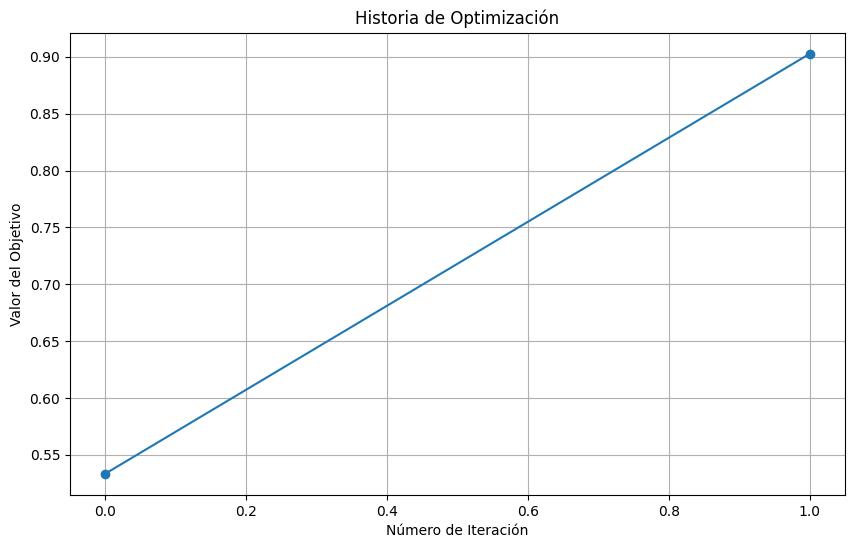

In [18]:
plt.figure(figsize=(10, 6))
trials = study.trials
values = [t.value for t in trials if t.value is not None]
iterations = list(range(len(values)))

plt.plot(iterations, values, marker='o')
plt.xlabel('Número de Iteración')
plt.ylabel('Valor del Objetivo')
plt.title('Historia de Optimización')
plt.grid(True)
plt.show()

Grafica de la importancia de los parametros

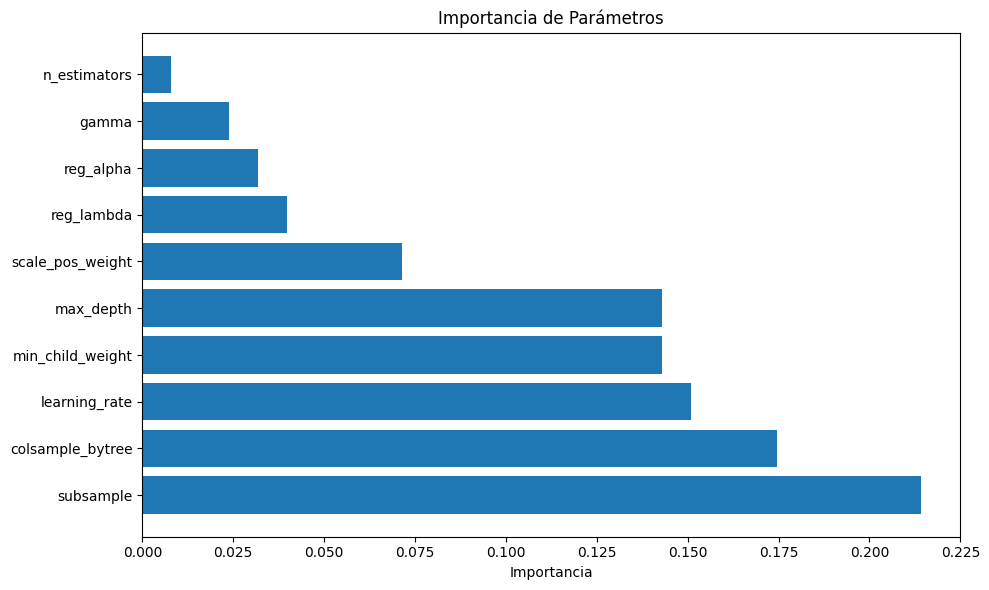

In [19]:
if len(study.trials) > 1:
    plt.figure(figsize=(10, 6))
    importance = optuna.importance.get_param_importances(study)
    
    # Ordenar por importancia
    sorted_importance = dict(sorted(importance.items(), key=lambda x: x[1], reverse=True))
    
    # Crear gráfico de barras
    plt.barh(list(sorted_importance.keys()), list(sorted_importance.values()))
    plt.xlabel('Importancia')
    plt.title('Importancia de Parámetros')
    plt.tight_layout()
    plt.show()